# MMM Benchmark Report Redesign

This notebook provides a two-level benchmark report:

1. **Executive overview** with global health and quality/runtime KPIs.
2. **Task deep-dives** with a consistent diagnostic template for every task.

It is designed to remain informative even when some runs fail or artifacts are missing.

Expected canonical inputs in `benchmark/results/latest/`:
- `run_results.csv`
- `paired_deltas.csv`
- `task_summary.csv`
- `benchmark_summary.csv`
- `run_results.jsonl`

Per-run artifacts are read from `benchmark/results/latest/artifacts/<task>/<mode>/seed_<seed>/`.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from pymc_marketing.paths import root

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

results_dir = root / "benchmark" / "results" / "latest"
artifacts_root = results_dir / "artifacts"

required_files = {
    "run_results": "run_results.csv",
    "paired_deltas": "paired_deltas.csv",
    "task_summary": "task_summary.csv",
    "benchmark_summary": "benchmark_summary.csv",
    "run_results_jsonl": "run_results.jsonl",
}

missing_required = [
    filename
    for filename in required_files.values()
    if not (results_dir / filename).exists()
]
if missing_required:
    raise FileNotFoundError(
        "Missing required benchmark files in latest results: "
        + ", ".join(missing_required)
    )


expected_run_columns = [
    "task_id",
    "task_type",
    "mode",
    "seed",
    "status",
    "runtime_sec",
    "folds_valid",
    "payload_validation_error_count",
    "artifacts_path",
]
expected_pair_columns = [
    "task_id",
    "seed",
]


def _warn_missing_columns(df: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = [col for col in expected if col not in df.columns]
    if missing:
        warnings.warn(
            f"{name}: missing expected columns: {missing}",
            stacklevel=2,
        )


def _coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    numeric_like = [
        col
        for col in out.columns
        if col.startswith("metric_")
        or col.startswith("delta_")
        or col.endswith("_sec")
        or col.endswith("_count")
    ]
    for col in numeric_like:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def _safe_json_load(path: Path):
    if not path.exists():
        return None
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def _artifact_state(path: Path) -> tuple[str, str]:
    if not path.exists():
        return "missing", "artifact file not found"

    if path.suffix == ".jsonl":
        with path.open(encoding="utf-8") as f:
            has_any = any(line.strip() for line in f)
        if not has_any:
            return "empty", "jsonl file exists but contains no events"
        return "available", "jsonl file contains events"

    payload = _safe_json_load(path)
    if payload is None:
        return "missing", "artifact file not found"
    if isinstance(payload, dict) and not payload:
        return "empty", "json object is empty"
    if isinstance(payload, list) and not payload:
        return "empty", "json array is empty"

    return "available", "artifact loaded"


run_df = _coerce_numeric(pd.read_csv(results_dir / required_files["run_results"]))
paired_df = _coerce_numeric(pd.read_csv(results_dir / required_files["paired_deltas"]))
task_df = _coerce_numeric(pd.read_csv(results_dir / required_files["task_summary"]))
benchmark_df = _coerce_numeric(
    pd.read_csv(results_dir / required_files["benchmark_summary"])
)

_warn_missing_columns(run_df, expected_run_columns, "run_results")
_warn_missing_columns(paired_df, expected_pair_columns, "paired_deltas")

expected_artifacts = [
    "fit_difference_context.json",
    "runtime_efficiency.json",
    "cv_fold_diagnostics_summary.json",
    "cv_parameter_stability.json",
    "fold_metrics.json",
    "cv_generalization_gap.json",
    "cv_fold_crps.json",
    "parameter_recovery_details.json",
    "roas_recovery_details.json",
    "agent_events.jsonl",
]

coverage_records: list[dict[str, object]] = []
for _, row in run_df.iterrows():
    base = Path(row.get("artifacts_path", ""))
    status = str(row.get("status", "unknown"))

    for artifact_name in expected_artifacts:
        artifact_path = base / artifact_name
        state, reason = _artifact_state(artifact_path)

        if state in {"missing", "empty"} and status != "success":
            reason = f"{reason}; run status={status}"

        coverage_records.append(
            {
                "task_id": row.get("task_id"),
                "mode": row.get("mode"),
                "seed": row.get("seed"),
                "status": status,
                "artifact_name": artifact_name,
                "artifact_state": state,
                "artifact_reason": reason,
                "artifact_path": str(artifact_path),
            }
        )

artifact_coverage_df = pd.DataFrame(coverage_records)
artifact_coverage_summary = (
    artifact_coverage_df.groupby(["task_id", "mode", "artifact_state"], as_index=False)
    .size()
    .rename(columns={"size": "artifact_count"})
)

print(f"Using results directory: {results_dir}")
print(
    f"Runs loaded: {len(run_df)} | tasks: {run_df['task_id'].nunique()} | modes: {run_df['mode'].nunique()}"
)

display(Markdown("### Data Contract Check"))
display(
    pd.DataFrame(
        {
            "dataset": [
                "run_results",
                "paired_deltas",
                "task_summary",
                "benchmark_summary",
            ],
            "rows": [len(run_df), len(paired_df), len(task_df), len(benchmark_df)],
            "columns": [
                run_df.shape[1],
                paired_df.shape[1],
                task_df.shape[1],
                benchmark_df.shape[1],
            ],
        }
    )
)

display(Markdown("### Artifact Coverage Snapshot"))
display(
    artifact_coverage_df.groupby(["artifact_name", "artifact_state"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values(["artifact_name", "artifact_state"])
)

run_df.head()

Using results directory: /Users/juanitorduz/Documents/pymc-marketing/benchmark/results/latest
Runs loaded: 6 | tasks: 3 | modes: 2


### Data Contract Check

,dataset,rows,columns
0,run_results,6,69
1,paired_deltas,3,29
2,task_summary,6,51
3,benchmark_summary,2,50


### Artifact Coverage Snapshot

,artifact_name,artifact_state,count
0,agent_events.jsonl,missing,6
1,cv_fold_crps.json,missing,6
2,cv_fold_diagnostics_summary.json,missing,6
3,cv_generalization_gap.json,missing,6
4,cv_parameter_stability.json,missing,6
5,fit_difference_context.json,missing,6
6,fold_metrics.json,missing,6
7,parameter_recovery_details.json,missing,6
8,roas_recovery_details.json,missing,6
9,runtime_efficiency.json,missing,6


,task_id,task_type,mode,seed,status,runtime_sec,dataset_path,sampler_nuts_sampler,sampler_chains,sampler_cores,sampler_draws,cv_n_folds,convergence_divergence_count,convergence_is_converged,fold_count_observed,folds_valid,metric_crps_oos,payload_validation_error_count,metric_convergence_divergence_count,metric_crps_cv_mean,metric_crps_cv_std,metric_cv_n_folds,metric_crps_train_cv_mean,metric_crps_train_cv_std,metric_crps_test_cv_mean,metric_crps_test_cv_std,metric_generalization_gap_mean,metric_generalization_gap_std,metric_generalization_gap_max,pass_no_divergence,pass_cv_fold_count,metric_in_sample_crps,metric_in_sample_rmse,metric_in_sample_mae,metric_cv_mean_crps,metric_cv_param_std_mean,metric_cv_param_iqr_mean,metric_cv_param_cv_mean,metric_cv_param_range_mean,metric_cv_param_count,metric_cv_divergence_mean,metric_cv_divergence_max,metric_cv_rhat_max,metric_cv_ess_bulk_min,metric_cv_bfmi_min,metric_runtime_sec,metric_runtime_per_fold_sec,metric_folds_per_second,artifacts_path,agent_events_path,metric_parameter_recovery_mae,metric_parameter_recovery_rmse,metric_parameter_recovery_median_ae,metric_parameter_recovery_max_ae,metric_parameter_recovery_shared_key_count,metric_parameter_recovery_missing_estimate_count,metric_parameter_recovery_missing_truth_count,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_roas_recovery_median_ae,metric_roas_recovery_max_ae,metric_roas_recovery_shared_key_count,metric_roas_recovery_missing_estimate_count,metric_roas_recovery_missing_truth_count,metric_crps_mean,metric_crps_std,metric_n_folds,metric_divergence_count,metric_rhat_max
0,mmm_case_study_1d,mmm_1d,baseline,42,success,468.995113,https://raw.githubusercontent.com/sibylhe/mmm_...,nutpie,4,4,1000,3,10,False,3,True,2.435746e+07,0,10.0,2.435746e+07,6.682145e+05,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,2.270392e+07,4.101092e+07,3.202348e+07,2.435746e+07,0.012038,0.014214,0.020533,0.028429,21.0,10.666667,20.0,1.01,602.0,NaN,468.995113,156.331704,0.006397,benchmark/results/latest/artifacts/mmm_case_st...,benchmark/results/latest/artifacts/mmm_case_st...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mmm_case_study_1d,mmm_1d,skilled,42,success,278.503424,https://raw.githubusercontent.com/sibylhe/mmm_...,nutpie,4,4,1000,3,1,False,3,True,2.089775e+07,0,1.0,2.089775e+07,2.834724e+06,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,2.213902e+07,4.056698e+07,3.118805e+07,2.089775e+07,0.037524,0.042952,0.062682,0.085905,21.0,3.666667,9.0,1.01,693.0,NaN,278.503424,92.834475,0.010772,benchmark/results/latest/artifacts/mmm_case_st...,benchmark/results/latest/artifacts/mmm_case_st...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mmm_multidimensional_recovery,mmm_multidimensional,baseline,42,failure,541.028602,data/mmm_multidimensional_example.csv,nutpie,4,4,1000,3,0,True,0,False,NaN,2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,541.028602,541.028602,0.001848,benchmark/results/latest/artifacts/mmm_multidi...,benchmark/results/latest/artifacts/mmm_multidi...,NaN,NaN,NaN,NaN,0.0,16.0,0.0,NaN,NaN,NaN,NaN,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN
3,mmm_multidimensional_recovery,mmm_multidimensional,skilled,42,failure,618.898836,data/mmm_multidimensional_example.csv,nutpie,4,4,1000,3,0,True,0,False,NaN,44,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,618.898836,618.898836,0.001616,benchmark/results/latest/artifacts/mmm_multidi...,benchmark/results/latest/artifacts/mmm_multidi...,NaN,NaN,NaN,NaN,0.0,16.0,0.0,NaN,NaN,NaN,NaN,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN
4,mmm_roas_confounding_calibration,mmm_roas_confounding,baseline,42,failure,758.741851,data/mmm_roas_data.csv,nutpie,4,4,1000,3,0,True,0,False,NaN,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,758.741851,758.741851,0.001318,benchmark/results/latest/arti

### Data Completeness and Artifact Coverage Visuals

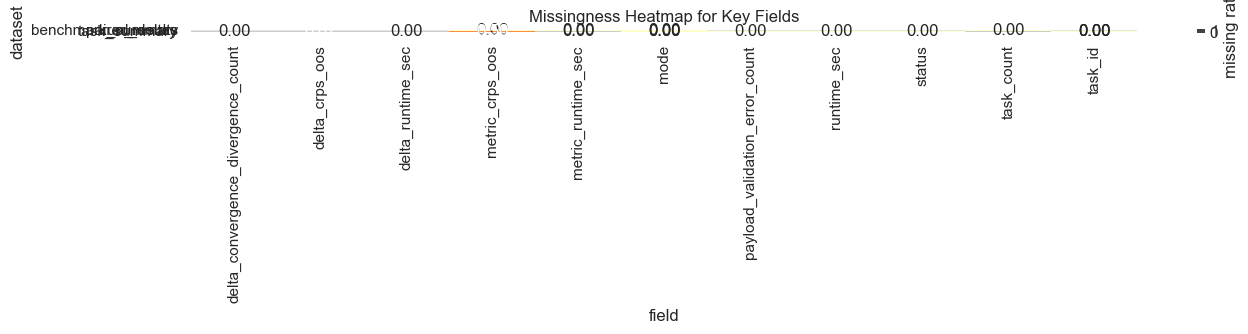

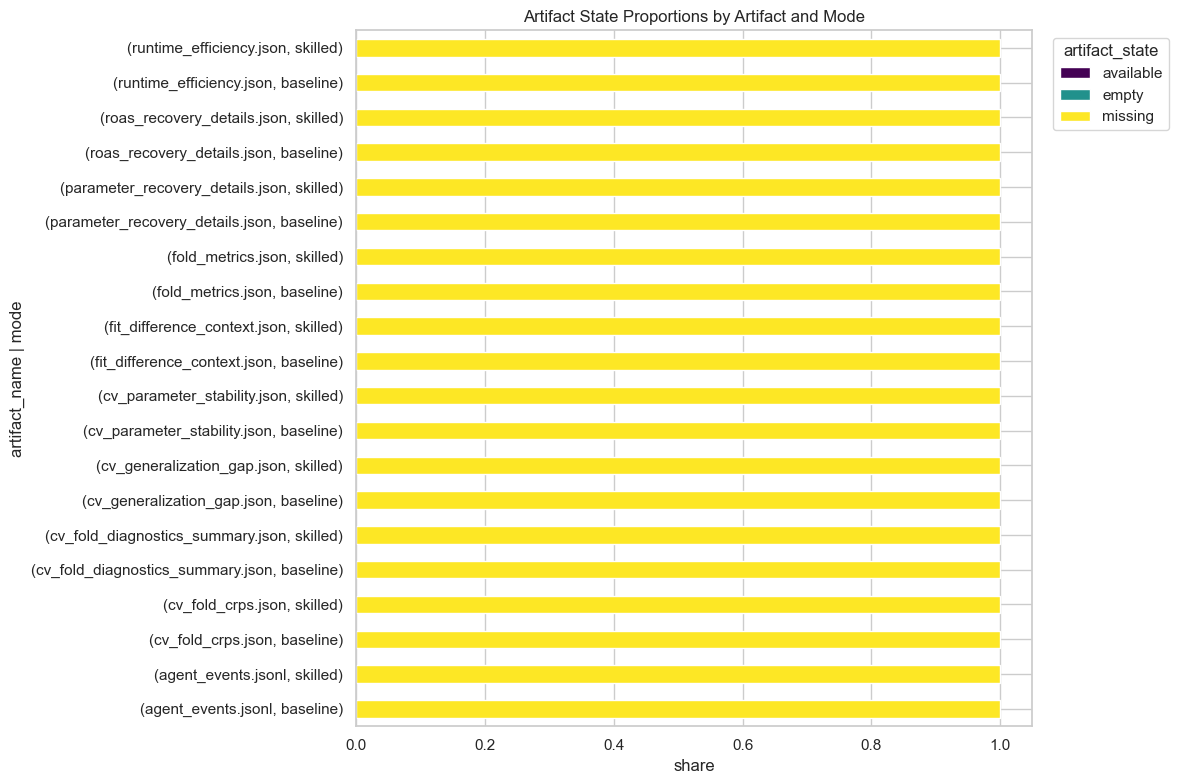

In [2]:
display(Markdown("### Data Completeness and Artifact Coverage Visuals"))

required_field_map = {
    "run_results": [
        "task_id",
        "mode",
        "status",
        "runtime_sec",
        "metric_crps_oos",
        "payload_validation_error_count",
    ],
    "paired_deltas": [
        "task_id",
        "delta_crps_oos",
        "delta_runtime_sec",
        "delta_convergence_divergence_count",
    ],
    "task_summary": [
        "task_id",
        "mode",
        "metric_crps_oos",
        "metric_runtime_sec",
    ],
    "benchmark_summary": [
        "mode",
        "metric_crps_oos",
        "metric_runtime_sec",
        "task_count",
    ],
}

frame_map = {
    "run_results": run_df,
    "paired_deltas": paired_df,
    "task_summary": task_df,
    "benchmark_summary": benchmark_df,
}

missingness_rows = []
for dataset_name, columns in required_field_map.items():
    frame = frame_map[dataset_name]
    for column in columns:
        if column not in frame.columns:
            missing_ratio = 1.0
        else:
            missing_ratio = frame[column].isna().mean()
        missingness_rows.append(
            {
                "dataset": dataset_name,
                "field": column,
                "missing_ratio": missing_ratio,
            }
        )

missingness_df = pd.DataFrame(missingness_rows)
missingness_pivot = missingness_df.pivot(
    index="dataset", columns="field", values="missing_ratio"
)

plt.figure(figsize=(14, 3.5))
sns.heatmap(
    missingness_pivot,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "missing ratio"},
)
plt.title("Missingness Heatmap for Key Fields")
plt.tight_layout()

coverage_share_df = (
    artifact_coverage_df.groupby(
        ["artifact_name", "mode", "artifact_state"], as_index=False
    )
    .size()
    .rename(columns={"size": "count"})
)
coverage_share_df["total"] = coverage_share_df.groupby(["artifact_name", "mode"])[
    "count"
].transform("sum")
coverage_share_df["share"] = coverage_share_df["count"] / coverage_share_df["total"]

pivot_share = coverage_share_df.pivot_table(
    index=["artifact_name", "mode"],
    columns="artifact_state",
    values="share",
    fill_value=0,
)

for state in ["available", "empty", "missing"]:
    if state not in pivot_share.columns:
        pivot_share[state] = 0.0

plot_share = pivot_share[["available", "empty", "missing"]]
ax = plot_share.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 8),
    colormap="viridis",
)
ax.set_title("Artifact State Proportions by Artifact and Mode")
ax.set_xlabel("share")
ax.set_ylabel("artifact_name | mode")
ax.legend(title="artifact_state", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Executive Overview

,mode,run_count,success_rate_pct,runtime_median_sec,runtime_total_sec,oos_crps_available_runs,oos_crps_median,mean_divergence_count,max_rhat,min_ess_bulk,artifact_availability_pct
0,baseline,3,33.333333,541.028602,1768.765566,1,2.435746e+07,3.333333,1.01,602.0,0.0
1,skilled,3,66.666667,618.898836,2968.916933,2,1.044909e+07,0.333333,1.02,377.0,0.0


### Baseline vs Skilled KPI Deltas

,metric,skilled_minus_baseline
0,success_rate_pct,3.333333e+01
1,runtime_median_sec,7.787023e+01
2,oos_crps_median,-1.390836e+07
3,mean_divergence_count,-3.000000e+00
4,artifact_availability_pct,0.000000e+00


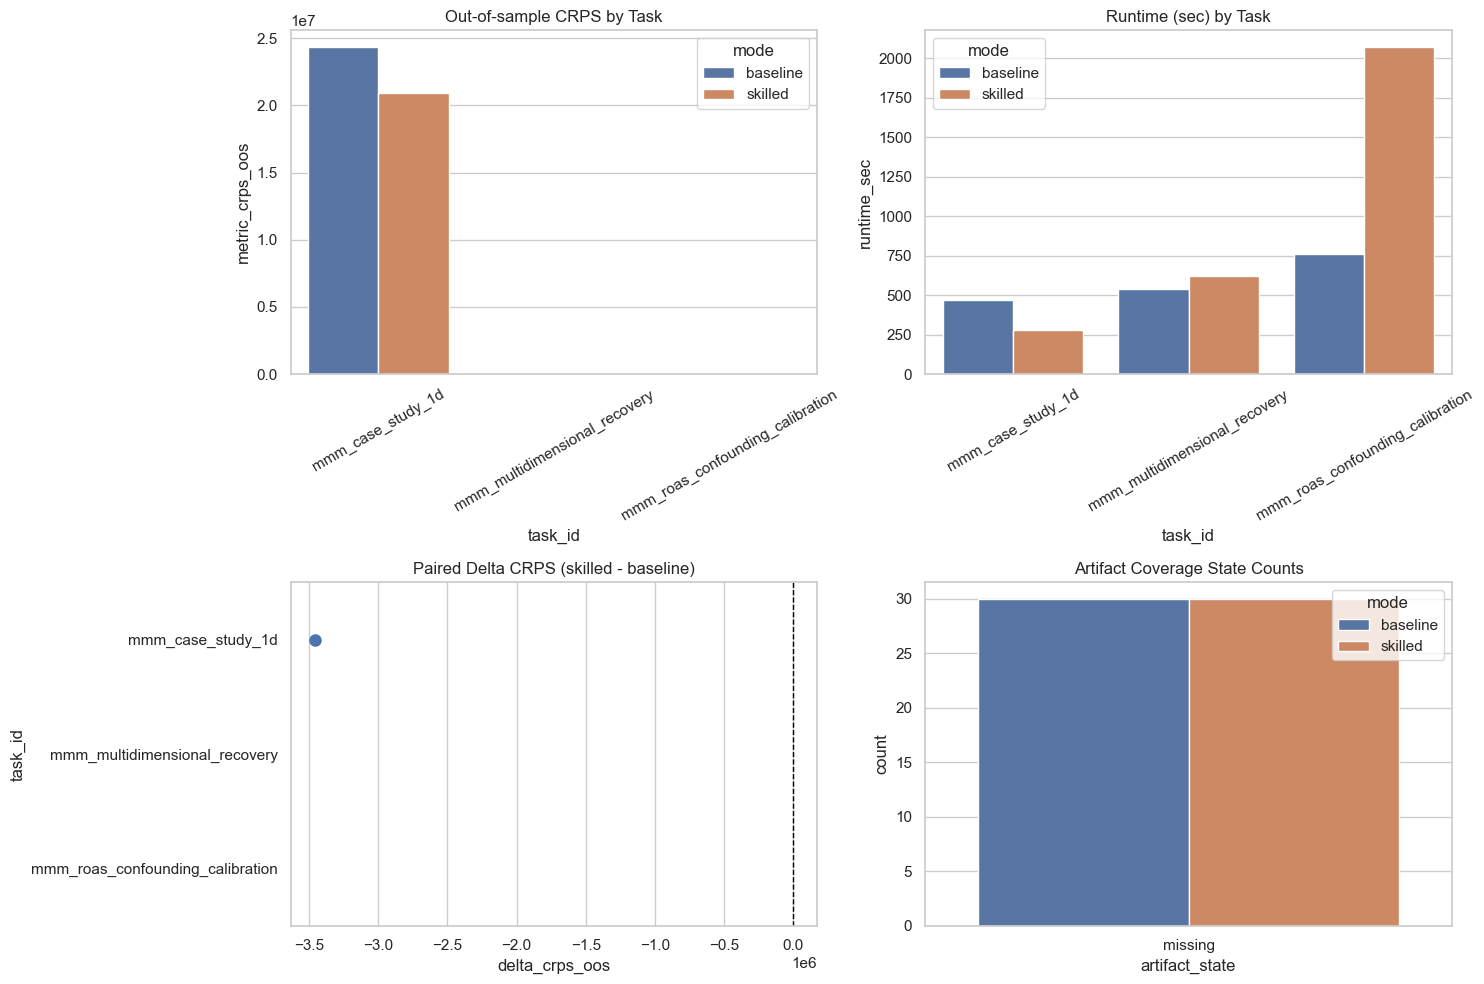

In [3]:
display(Markdown("## Executive Overview"))

kpi_rows = []
for mode, mode_df in run_df.groupby("mode"):
    success_rate = (mode_df["status"] == "success").mean() * 100
    runtime_median = mode_df["runtime_sec"].median()
    runtime_total = mode_df["runtime_sec"].sum()

    crps_available = mode_df["metric_crps_oos"].notna().sum()
    crps_median = mode_df["metric_crps_oos"].median()

    divergence_mean = mode_df["metric_convergence_divergence_count"].mean()
    rhat_max = mode_df["metric_cv_rhat_max"].max()
    ess_bulk_min = mode_df["metric_cv_ess_bulk_min"].min()

    coverage_subset = artifact_coverage_df[artifact_coverage_df["mode"] == mode]
    coverage_rate = (
        (coverage_subset["artifact_state"] == "available").mean() * 100
        if not coverage_subset.empty
        else np.nan
    )

    kpi_rows.append(
        {
            "mode": mode,
            "run_count": len(mode_df),
            "success_rate_pct": success_rate,
            "runtime_median_sec": runtime_median,
            "runtime_total_sec": runtime_total,
            "oos_crps_available_runs": crps_available,
            "oos_crps_median": crps_median,
            "mean_divergence_count": divergence_mean,
            "max_rhat": rhat_max,
            "min_ess_bulk": ess_bulk_min,
            "artifact_availability_pct": coverage_rate,
        }
    )

kpi_df = pd.DataFrame(kpi_rows).sort_values("mode")
display(kpi_df)

if {"baseline", "skilled"}.issubset(set(kpi_df["mode"])):
    baseline_row = kpi_df[kpi_df["mode"] == "baseline"].iloc[0]
    skilled_row = kpi_df[kpi_df["mode"] == "skilled"].iloc[0]
    delta_table = pd.DataFrame(
        {
            "metric": [
                "success_rate_pct",
                "runtime_median_sec",
                "oos_crps_median",
                "mean_divergence_count",
                "artifact_availability_pct",
            ],
            "skilled_minus_baseline": [
                skilled_row["success_rate_pct"] - baseline_row["success_rate_pct"],
                skilled_row["runtime_median_sec"] - baseline_row["runtime_median_sec"],
                skilled_row["oos_crps_median"] - baseline_row["oos_crps_median"],
                skilled_row["mean_divergence_count"]
                - baseline_row["mean_divergence_count"],
                skilled_row["artifact_availability_pct"]
                - baseline_row["artifact_availability_pct"],
            ],
        }
    )
    display(Markdown("### Baseline vs Skilled KPI Deltas"))
    display(delta_table)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

if "metric_crps_oos" in run_df.columns:
    sns.barplot(
        data=run_df,
        x="task_id",
        y="metric_crps_oos",
        hue="mode",
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Out-of-sample CRPS by Task")
    axes[0, 0].tick_params(axis="x", rotation=30)
else:
    axes[0, 0].text(0.1, 0.5, "metric_crps_oos not available")
    axes[0, 0].set_axis_off()

sns.barplot(
    data=run_df,
    x="task_id",
    y="runtime_sec",
    hue="mode",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Runtime (sec) by Task")
axes[0, 1].tick_params(axis="x", rotation=30)

if "delta_crps_oos" in paired_df.columns:
    sns.stripplot(
        data=paired_df,
        y="task_id",
        x="delta_crps_oos",
        orient="h",
        size=9,
        jitter=False,
        ax=axes[1, 0],
    )
    axes[1, 0].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[1, 0].set_title("Paired Delta CRPS (skilled - baseline)")
else:
    axes[1, 0].text(0.1, 0.5, "delta_crps_oos not available")
    axes[1, 0].set_axis_off()

coverage_plot = (
    artifact_coverage_df.groupby(["mode", "artifact_state"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
sns.barplot(
    data=coverage_plot,
    x="artifact_state",
    y="count",
    hue="mode",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Artifact Coverage State Counts")

plt.tight_layout()

### Executive Comparison Visuals

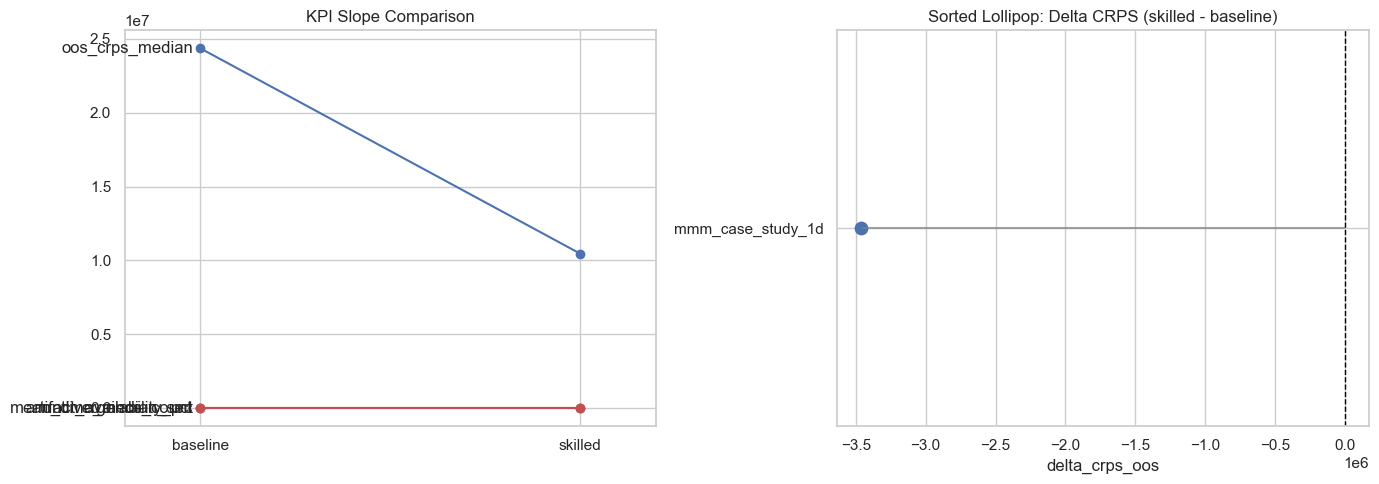

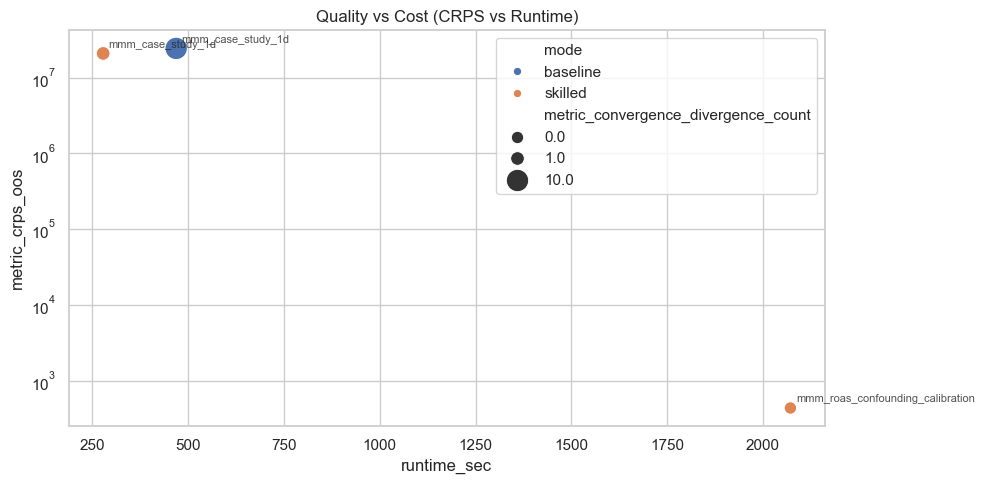

In [4]:
display(Markdown("### Executive Comparison Visuals"))

if {"baseline", "skilled"}.issubset(set(kpi_df["mode"])):
    compare_metrics = [
        "oos_crps_median",
        "runtime_median_sec",
        "mean_divergence_count",
        "artifact_availability_pct",
    ]

    slope_rows = []
    for metric in compare_metrics:
        base_value = float(kpi_df.loc[kpi_df["mode"] == "baseline", metric].iloc[0])
        skill_value = float(kpi_df.loc[kpi_df["mode"] == "skilled", metric].iloc[0])
        slope_rows.append(
            {
                "metric": metric,
                "baseline": base_value,
                "skilled": skill_value,
            }
        )

    slope_df = pd.DataFrame(slope_rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for _, row in slope_df.iterrows():
        axes[0].plot([0, 1], [row["baseline"], row["skilled"]], marker="o")
        axes[0].text(-0.02, row["baseline"], row["metric"], ha="right", va="center")

    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["baseline", "skilled"])
    axes[0].set_title("KPI Slope Comparison")
    axes[0].set_xlim(-0.2, 1.2)

    if "delta_crps_oos" in paired_df.columns:
        lollipop_df = (
            paired_df[["task_id", "delta_crps_oos"]]
            .dropna()
            .sort_values("delta_crps_oos")
        )
        axes[1].hlines(
            y=lollipop_df["task_id"],
            xmin=0,
            xmax=lollipop_df["delta_crps_oos"],
            color="gray",
            alpha=0.7,
        )
        axes[1].scatter(
            lollipop_df["delta_crps_oos"],
            lollipop_df["task_id"],
            s=80,
        )
        axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
        axes[1].set_title("Sorted Lollipop: Delta CRPS (skilled - baseline)")
        axes[1].set_xlabel("delta_crps_oos")
    else:
        axes[1].text(0.1, 0.5, "delta_crps_oos not available")
        axes[1].set_axis_off()

    plt.tight_layout()

scatter_cols = [
    "task_id",
    "mode",
    "metric_crps_oos",
    "runtime_sec",
    "metric_convergence_divergence_count",
]
scatter_cols = [c for c in scatter_cols if c in run_df.columns]
quality_cost_df = (
    run_df[scatter_cols].dropna(subset=["metric_crps_oos", "runtime_sec"])
    if {"metric_crps_oos", "runtime_sec"}.issubset(set(scatter_cols))
    else pd.DataFrame()
)

if quality_cost_df.empty:
    display(
        Markdown(
            "Quality-vs-cost scatter not available because required metrics are missing."
        )
    )
else:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=quality_cost_df,
        x="runtime_sec",
        y="metric_crps_oos",
        hue="mode",
        size="metric_convergence_divergence_count"
        if "metric_convergence_divergence_count" in quality_cost_df.columns
        else None,
        sizes=(80, 260),
    )

    for _, row in quality_cost_df.iterrows():
        plt.annotate(
            row["task_id"],
            (row["runtime_sec"], row["metric_crps_oos"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    if (
        quality_cost_df["metric_crps_oos"].max()
        / max(quality_cost_df["metric_crps_oos"].min(), 1e-12)
        > 50
    ):
        plt.yscale("log")
    plt.title("Quality vs Cost (CRPS vs Runtime)")
    plt.xlabel("runtime_sec")
    plt.ylabel("metric_crps_oos")
    plt.tight_layout()

## Task Triage Board

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_76476/1104349242.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  artifact_coverage_df.groupby("task_id").apply(


,task_id,mode,success_rate,failure_count,folds_valid_rate,payload_validation_error_count,missing_artifacts,delta_crps_oos,delta_runtime_sec,delta_parameter_recovery_mae,delta_roas_recovery_mae,attention_priority
3,mmm_multidimensional_recovery,skilled,0.0,1,0.0,44,20,NaN,77.870234,NaN,NaN,81.0
4,mmm_roas_confounding_calibration,baseline,0.0,1,0.0,3,20,NaN,1312.772821,NaN,NaN,60.5
2,mmm_multidimensional_recovery,baseline,0.0,1,0.0,2,20,NaN,77.870234,NaN,NaN,60.0
5,mmm_roas_confounding_calibration,skilled,1.0,0,1.0,0,20,NaN,1312.772821,NaN,NaN,9.0
0,mmm_case_study_1d,baseline,1.0,0,1.0,0,20,-3.459705e+06,-190.491689,NaN,NaN,4.0
1,mmm_case_study_1d,skilled,1.0,0,1.0,0,20,-3.459705e+06,-190.491689,NaN,NaN,4.0


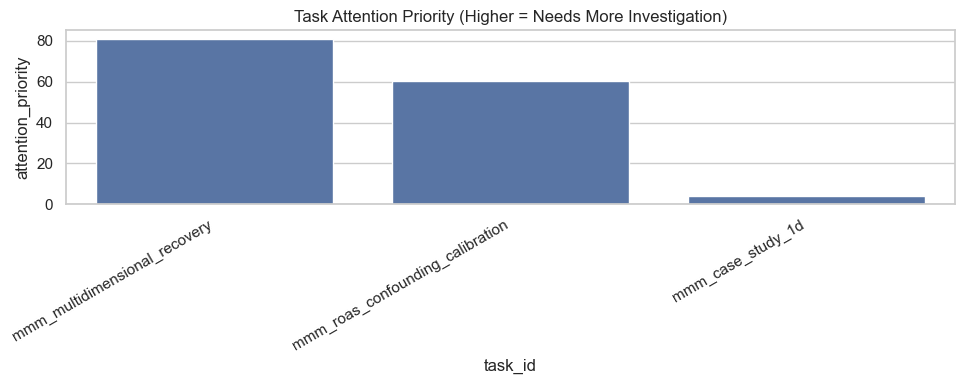

In [5]:
display(Markdown("## Task Triage Board"))

status_df = (
    run_df.assign(is_success=run_df["status"].eq("success").astype(int))
    .groupby(["task_id", "mode"], as_index=False)
    .agg(
        run_count=("status", "size"),
        success_count=("is_success", "sum"),
        failure_count=("is_success", lambda s: int((1 - s).sum())),
        folds_valid_rate=("folds_valid", "mean"),
        payload_validation_error_count=("payload_validation_error_count", "sum"),
        runtime_sec_median=("runtime_sec", "median"),
        oos_crps_available=("metric_crps_oos", lambda s: int(s.notna().sum())),
        cv_param_available=("metric_cv_param_std_mean", lambda s: int(s.notna().sum())),
        roas_recovery_available=(
            "metric_roas_recovery_mae",
            lambda s: int(s.notna().sum()),
        ),
    )
)
status_df["success_rate"] = status_df["success_count"] / status_df["run_count"]

triage_df = status_df.merge(
    paired_df,
    on="task_id",
    how="left",
)

for col in [
    "delta_crps_oos",
    "delta_runtime_sec",
    "delta_runtime_per_fold_sec",
    "delta_convergence_divergence_count",
    "delta_cv_rhat_max",
    "delta_parameter_recovery_mae",
    "delta_roas_recovery_mae",
]:
    if col not in triage_df.columns:
        triage_df[col] = np.nan

triage_df["missing_artifacts"] = triage_df["task_id"].map(
    artifact_coverage_df.groupby("task_id").apply(
        lambda s: int((s["artifact_state"] != "available").sum())
    )
)

triage_df["attention_priority"] = (
    50 * (1 - triage_df["success_rate"].fillna(0))
    + 0.5 * triage_df["payload_validation_error_count"].fillna(0)
    + 0.2 * triage_df["missing_artifacts"].fillna(0)
    + 10 * triage_df["delta_crps_oos"].fillna(0).gt(0).astype(int)
    + 5 * triage_df["delta_runtime_sec"].fillna(0).gt(0).astype(int)
)

triage_view_cols = [
    "task_id",
    "mode",
    "success_rate",
    "failure_count",
    "folds_valid_rate",
    "payload_validation_error_count",
    "missing_artifacts",
    "delta_crps_oos",
    "delta_runtime_sec",
    "delta_parameter_recovery_mae",
    "delta_roas_recovery_mae",
    "attention_priority",
]

triage_view = triage_df[triage_view_cols].sort_values(
    ["attention_priority", "task_id", "mode"],
    ascending=[False, True, True],
)

display(triage_view)

plot_df = (
    triage_view.groupby("task_id", as_index=False)
    .agg(attention_priority=("attention_priority", "max"))
    .sort_values("attention_priority", ascending=False)
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="task_id", y="attention_priority")
plt.title("Task Attention Priority (Higher = Needs More Investigation)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

### Triage Driver Visuals

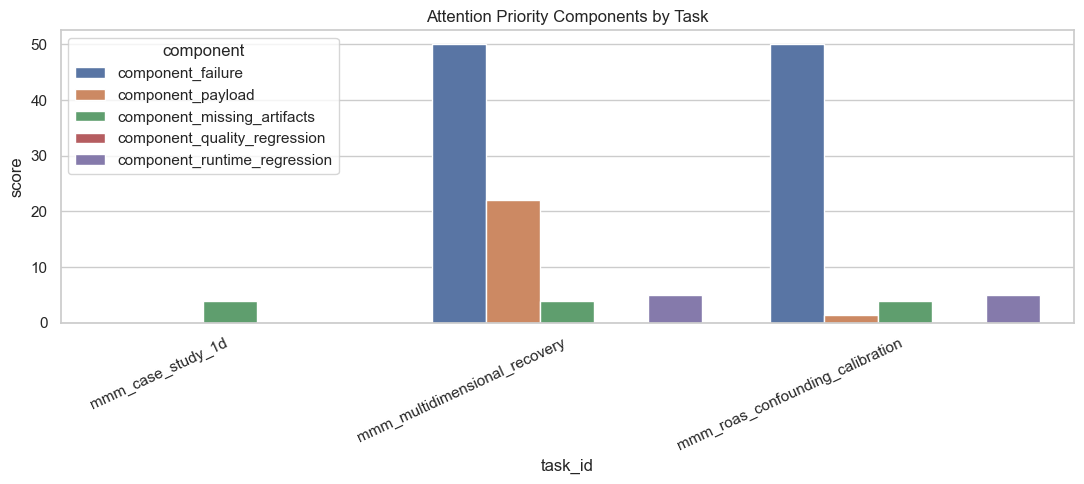

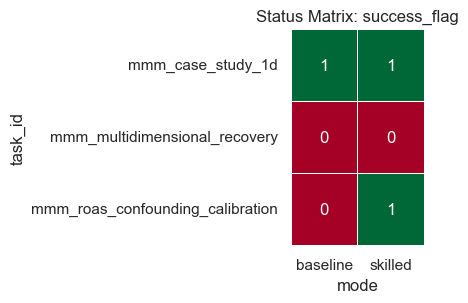

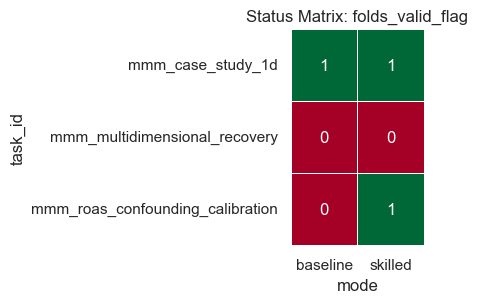

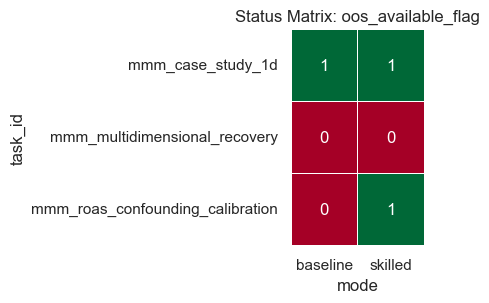

In [6]:
display(Markdown("### Triage Driver Visuals"))

triage_components = triage_df.copy()
triage_components["component_failure"] = 50 * (
    1 - triage_components["success_rate"].fillna(0)
)
triage_components["component_payload"] = 0.5 * triage_components[
    "payload_validation_error_count"
].fillna(0)
triage_components["component_missing_artifacts"] = 0.2 * triage_components[
    "missing_artifacts"
].fillna(0)
triage_components["component_quality_regression"] = 10 * triage_components[
    "delta_crps_oos"
].fillna(0).gt(0).astype(int)
triage_components["component_runtime_regression"] = 5 * triage_components[
    "delta_runtime_sec"
].fillna(0).gt(0).astype(int)

component_cols = [
    "component_failure",
    "component_payload",
    "component_missing_artifacts",
    "component_quality_regression",
    "component_runtime_regression",
]

component_plot_df = (
    triage_components.groupby("task_id", as_index=False)[component_cols]
    .max()
    .sort_values("task_id")
)

component_long = component_plot_df.melt(
    id_vars=["task_id"],
    var_name="component",
    value_name="score",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=component_long, x="task_id", y="score", hue="component")
plt.title("Attention Priority Components by Task")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

status_matrix = triage_df.copy()
status_matrix["success_flag"] = status_matrix["success_rate"].ge(1.0).astype(int)
status_matrix["folds_valid_flag"] = (
    status_matrix["folds_valid_rate"].ge(1.0).astype(int)
)
status_matrix["oos_available_flag"] = (
    status_matrix["oos_crps_available"].gt(0).astype(int)
)

for health_metric in ["success_flag", "folds_valid_flag", "oos_available_flag"]:
    pivot = status_matrix.pivot(index="task_id", columns="mode", values=health_metric)
    plt.figure(figsize=(4.5, 3.2))
    sns.heatmap(
        pivot,
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        annot=True,
        cbar=False,
        fmt=".0f",
        linewidths=0.5,
    )
    plt.title(f"Status Matrix: {health_metric}")
    plt.tight_layout()

## Per-Task Deep Dives

### Task: `mmm_case_study_1d`

#### Run Health

,task_id,mode,status,folds_valid,fold_count_observed,payload_validation_error_count,metric_convergence_divergence_count,metric_cv_rhat_max,metric_cv_ess_bulk_min
0,mmm_case_study_1d,baseline,success,True,3,0,10.0,1.01,602.0
1,mmm_case_study_1d,skilled,success,True,3,0,1.0,1.01,693.0


#### Performance

...

#### Artifact Coverage

,task_id,mode,seed,artifact_name,artifact_state,artifact_reason
49,mmm_roas_confounding_calibration,baseline,42,agent_events.jsonl,missing,artifact file not found; run status=failure
46,mmm_roas_confounding_calibration,baseline,42,cv_fold_crps.json,missing,artifact file not found; run status=failure
42,mmm_roas_confounding_calibration,baseline,42,cv_fold_diagnostics_summary.json,missing,artifact file not found; run status=failure
45,mmm_roas_confounding_calibration,baseline,42,cv_generalization_gap.json,missing,artifact file not found; run status=failure
43,mmm_roas_confounding_calibration,baseline,42,cv_parameter_stability.json,missing,artifact file not found; run status=failure
40,mmm_roas_confounding_calibration,baseline,42,fit_difference_context.json,missing,artifact file not found; run status=failure
44,mmm_roas_confounding_calibration,baseline,42,fold_metrics.json,missing,artifact file not found; run status=failure
47,mmm_roas_confounding_calibration,baseline,42,parameter_recovery_details.json,missing,artifact file not found; run status=failure
48,mmm_roas_confounding_calibration,baseline,42,roas_recovery_details.json,missing,artifact file not found; run status=failure
41,mmm_roas_confounding_calibration,baseline,42,runtime_efficiency.json,missing,artifact file not found; run status=failure


#### Interpretation Summary

- Skilled is slower in total runtime (delta=1312.77s).

- Failure observed in modes: baseline.

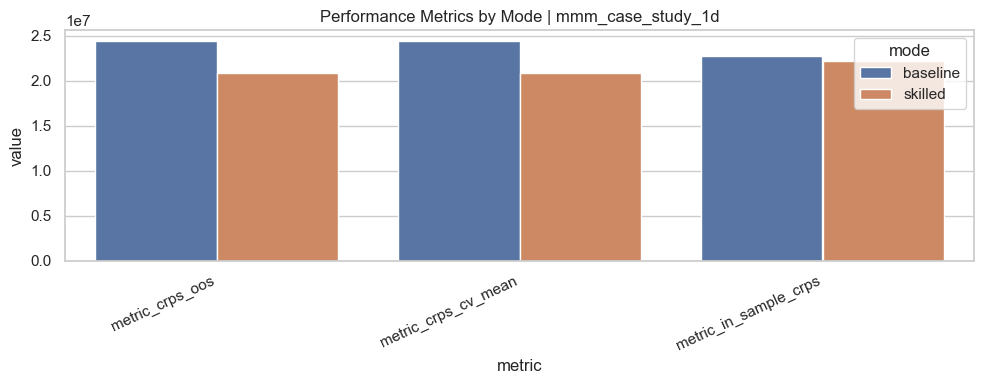

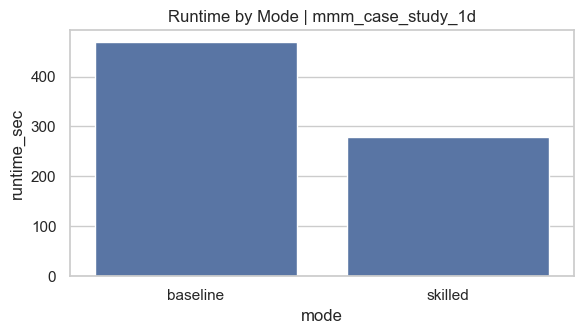

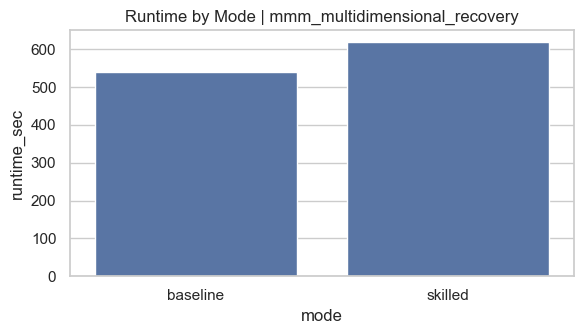

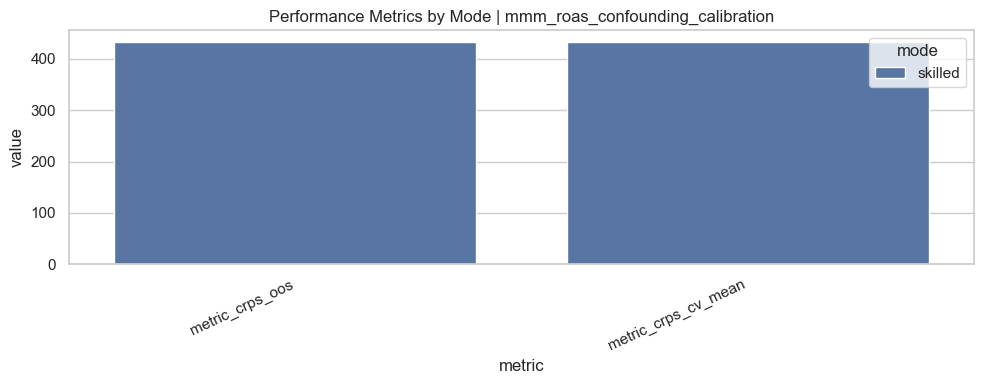

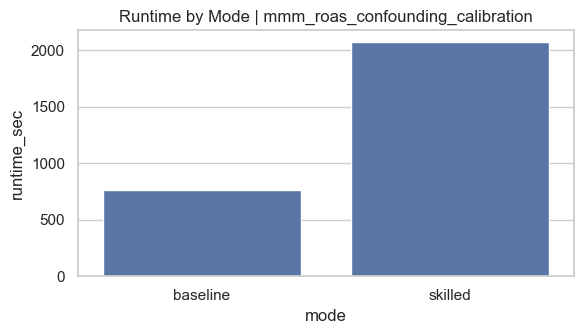

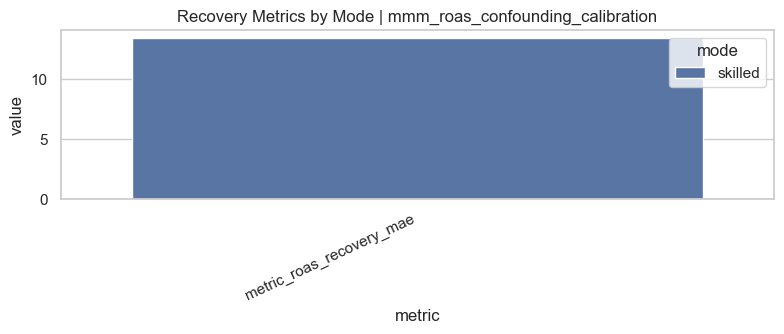

In [7]:
display(Markdown("## Per-Task Deep Dives"))


def _status_panel(task_runs: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "task_id",
        "mode",
        "status",
        "folds_valid",
        "fold_count_observed",
        "payload_validation_error_count",
        "metric_convergence_divergence_count",
        "metric_cv_rhat_max",
        "metric_cv_ess_bulk_min",
    ]
    cols = [c for c in cols if c in task_runs.columns]
    return task_runs[cols].sort_values("mode")


def _performance_panel(task_runs: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "task_id",
        "mode",
        "metric_crps_oos",
        "metric_crps_cv_mean",
        "metric_crps_cv_std",
        "metric_in_sample_crps",
        "metric_in_sample_rmse",
        "metric_in_sample_mae",
        "metric_generalization_gap_mean",
    ]
    cols = [c for c in cols if c in task_runs.columns]
    return task_runs[cols].sort_values("mode")


def _runtime_panel(task_runs: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "task_id",
        "mode",
        "runtime_sec",
        "metric_runtime_per_fold_sec",
        "metric_folds_per_second",
    ]
    cols = [c for c in cols if c in task_runs.columns]
    return task_runs[cols].sort_values("mode")


def _stability_panel(task_runs: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "task_id",
        "mode",
        "metric_cv_param_std_mean",
        "metric_cv_param_iqr_mean",
        "metric_cv_param_cv_mean",
        "metric_cv_param_range_mean",
        "metric_cv_divergence_mean",
        "metric_cv_divergence_max",
        "metric_cv_rhat_max",
        "metric_cv_ess_bulk_min",
    ]
    cols = [c for c in cols if c in task_runs.columns]
    return task_runs[cols].sort_values("mode")


def _recovery_panel(task_runs: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "task_id",
        "mode",
        "metric_parameter_recovery_mae",
        "metric_parameter_recovery_rmse",
        "metric_parameter_recovery_shared_key_count",
        "metric_parameter_recovery_missing_estimate_count",
        "metric_parameter_recovery_missing_truth_count",
        "metric_roas_recovery_mae",
        "metric_roas_recovery_rmse",
        "metric_roas_recovery_shared_key_count",
        "metric_roas_recovery_missing_estimate_count",
        "metric_roas_recovery_missing_truth_count",
    ]
    cols = [c for c in cols if c in task_runs.columns]
    return task_runs[cols].sort_values("mode")


def _interpretation(task_id: str, task_runs: pd.DataFrame) -> list[str]:
    messages = []
    pair_row = paired_df[paired_df["task_id"] == task_id]

    if not pair_row.empty:
        pair = pair_row.iloc[0]
        delta_crps = pair.get("delta_crps_oos")
        if pd.notna(delta_crps):
            direction = "improves" if delta_crps < 0 else "worsens"
            messages.append(
                f"Skilled {direction} out-of-sample CRPS (delta={delta_crps:.4g})."
            )

        delta_runtime = pair.get("delta_runtime_sec")
        if pd.notna(delta_runtime):
            speed = "faster" if delta_runtime < 0 else "slower"
            messages.append(
                f"Skilled is {speed} in total runtime (delta={delta_runtime:.2f}s)."
            )

        delta_div = pair.get("delta_convergence_divergence_count")
        if pd.notna(delta_div):
            if delta_div < 0:
                messages.append("Skilled reduces divergence count.")
            elif delta_div > 0:
                messages.append("Skilled increases divergence count.")

    failed_modes = task_runs.loc[task_runs["status"] != "success", "mode"].tolist()
    if failed_modes:
        messages.append(f"Failure observed in modes: {', '.join(failed_modes)}.")

    if not messages:
        messages.append(
            "No strong comparative signal available due to missing deltas or metrics."
        )

    return messages


for task_id in sorted(run_df["task_id"].unique()):
    task_runs = run_df[run_df["task_id"] == task_id].copy()
    display(Markdown(f"### Task: `{task_id}`"))

    display(Markdown("#### Run Health"))
    display(_status_panel(task_runs))

    display(Markdown("#### Performance"))
    perf_df = _performance_panel(task_runs)
    display(perf_df)

    key_plot_cols = [
        "metric_crps_oos",
        "metric_crps_cv_mean",
        "metric_in_sample_crps",
    ]
    key_plot_cols = [c for c in key_plot_cols if c in task_runs.columns]
    if key_plot_cols:
        perf_long = task_runs[["mode", *key_plot_cols]].melt(
            id_vars=["mode"],
            var_name="metric",
            value_name="value",
        )
        perf_long = perf_long.dropna(subset=["value"])
        if not perf_long.empty:
            plt.figure(figsize=(10, 4))
            sns.barplot(data=perf_long, x="metric", y="value", hue="mode")
            plt.title(f"Performance Metrics by Mode | {task_id}")
            plt.xticks(rotation=25, ha="right")
            plt.tight_layout()
        else:
            display(
                Markdown(
                    "_Performance metrics exist but values are missing for this task._"
                )
            )
    else:
        display(Markdown("_Performance metrics not available for this task._"))

    display(Markdown("#### Runtime Efficiency"))
    runtime_df = _runtime_panel(task_runs)
    display(runtime_df)

    if "runtime_sec" in task_runs.columns:
        plt.figure(figsize=(6, 3.5))
        sns.barplot(data=task_runs, x="mode", y="runtime_sec")
        plt.title(f"Runtime by Mode | {task_id}")
        plt.tight_layout()

    display(Markdown("#### Stability and Diagnostics"))
    stability_df = _stability_panel(task_runs)
    display(stability_df)

    detail_records = []
    for _, row in task_runs.iterrows():
        base = Path(row.get("artifacts_path", ""))
        details_path = base / "cv_parameter_stability.json"
        details_payload = _safe_json_load(details_path)
        by_parameter = (
            details_payload.get("by_parameter", {})
            if isinstance(details_payload, dict)
            else {}
        )
        if by_parameter:
            for param_name, stats in by_parameter.items():
                detail_records.append(
                    {
                        "mode": row.get("mode"),
                        "parameter": param_name,
                        "std": stats.get("std"),
                        "iqr": stats.get("iqr"),
                        "coefvar": stats.get("coefvar"),
                        "n_folds": stats.get("n_folds"),
                    }
                )

    detail_df = pd.DataFrame(detail_records)
    if detail_df.empty:
        display(
            Markdown(
                "_CV parameter stability details not produced or empty for this task._"
            )
        )
    else:
        top_std = (
            detail_df.sort_values("std", ascending=False)
            .groupby("mode", as_index=False)
            .head(5)
        )
        display(top_std)

    display(Markdown("#### Recovery Metrics"))
    recovery_df = _recovery_panel(task_runs)
    display(recovery_df)

    recovery_values = [
        "metric_parameter_recovery_mae",
        "metric_roas_recovery_mae",
    ]
    available_recovery_values = [c for c in recovery_values if c in task_runs.columns]
    if available_recovery_values:
        recovery_plot_df = task_runs[["mode", *available_recovery_values]].melt(
            id_vars=["mode"],
            var_name="metric",
            value_name="value",
        )
        recovery_plot_df = recovery_plot_df.dropna(subset=["value"])
        if recovery_plot_df.empty:
            display(
                Markdown(
                    "_Recovery section available but no finite recovery values for this task._"
                )
            )
        else:
            plt.figure(figsize=(8, 3.5))
            sns.barplot(data=recovery_plot_df, x="metric", y="value", hue="mode")
            plt.title(f"Recovery Metrics by Mode | {task_id}")
            plt.xticks(rotation=25, ha="right")
            plt.tight_layout()
    else:
        display(Markdown("_Recovery metrics are not expected for this task type._"))

    display(Markdown("#### Artifact Coverage"))
    coverage_view = artifact_coverage_df[
        artifact_coverage_df["task_id"] == task_id
    ].copy()
    display(
        coverage_view[
            [
                "task_id",
                "mode",
                "seed",
                "artifact_name",
                "artifact_state",
                "artifact_reason",
            ]
        ].sort_values(["mode", "artifact_name"])
    )

    display(Markdown("#### Interpretation Summary"))
    for bullet in _interpretation(task_id, task_runs):
        display(Markdown(f"- {bullet}"))

## Per-Task Visual Enhancements

### Visual Layer: `mmm_case_study_1d`

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_76476/1220992821.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


_Parameter stability heatmap not available for this task._

_Recovery coverage panel unavailable for this task._

...

_No finite performance values available for normalized comparison._

_Parameter stability heatmap not available for this task._

### Visual Layer: `mmm_roas_confounding_calibration`

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_76476/1220992821.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


_Parameter stability heatmap not available for this task._

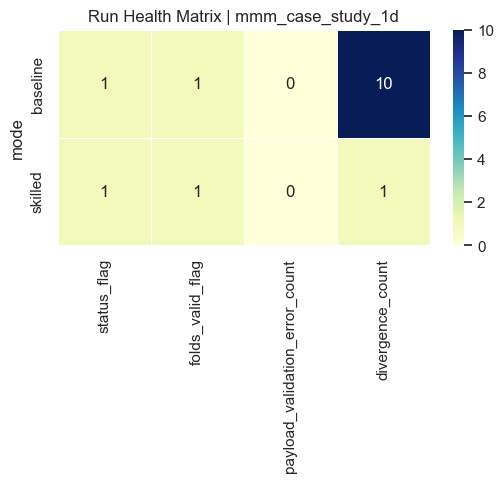

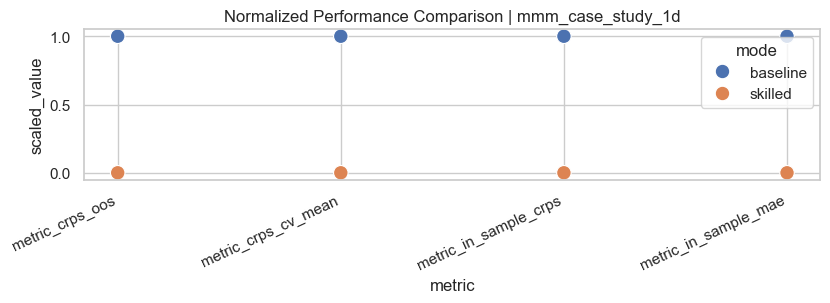

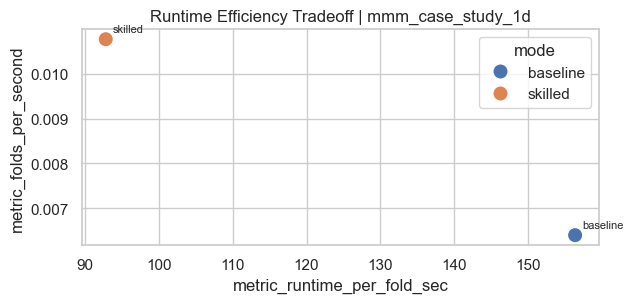

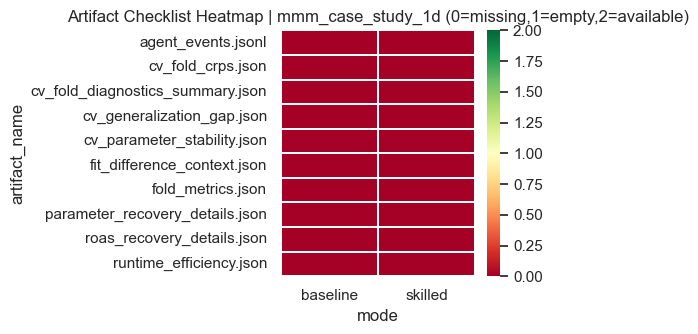

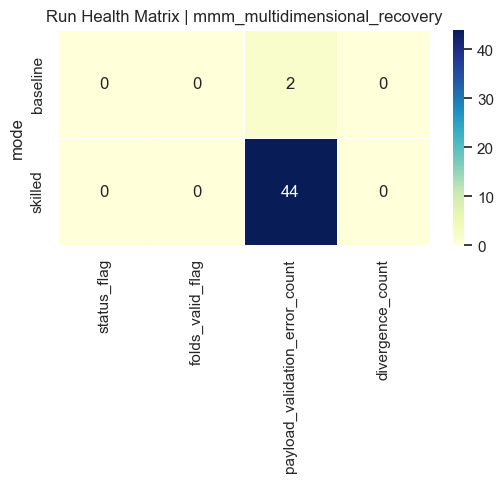

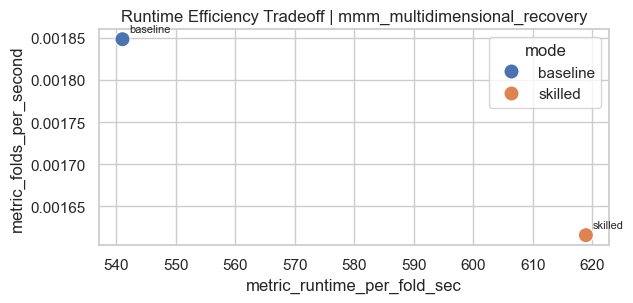

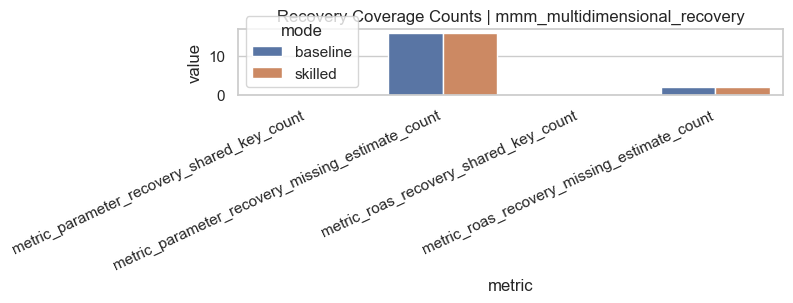

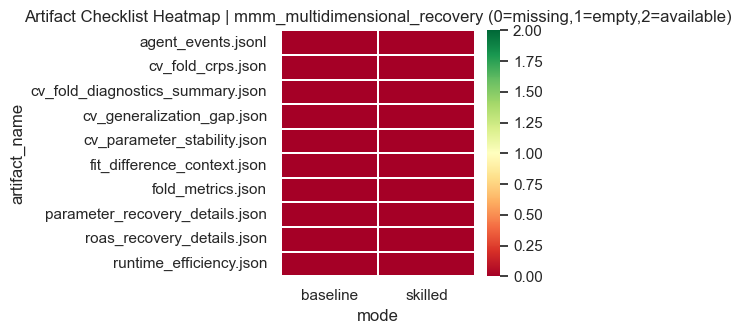

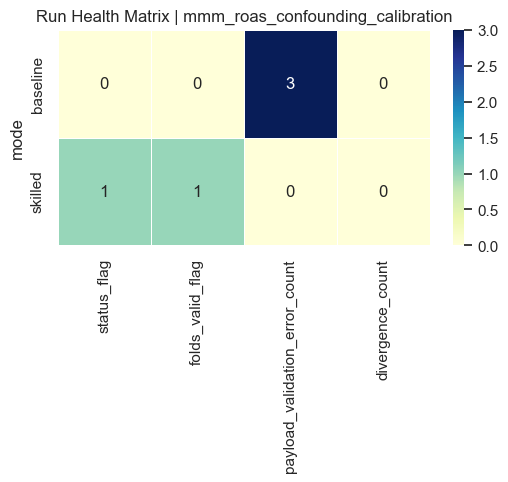

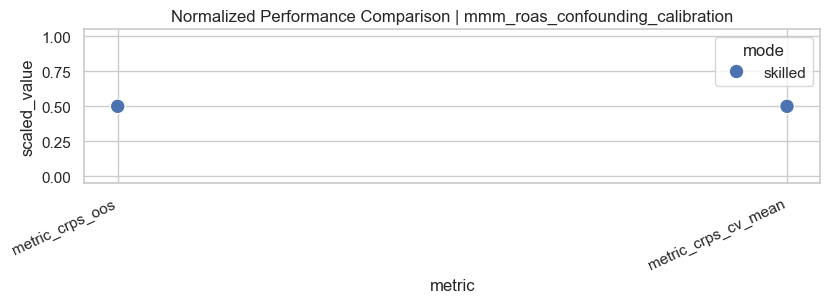

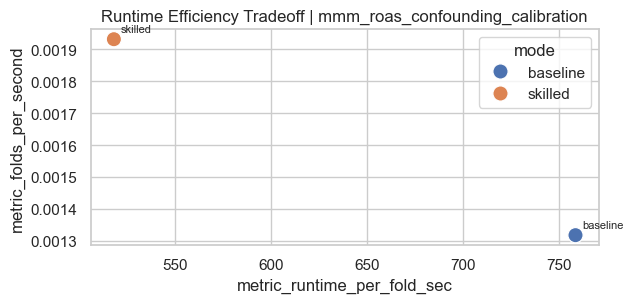

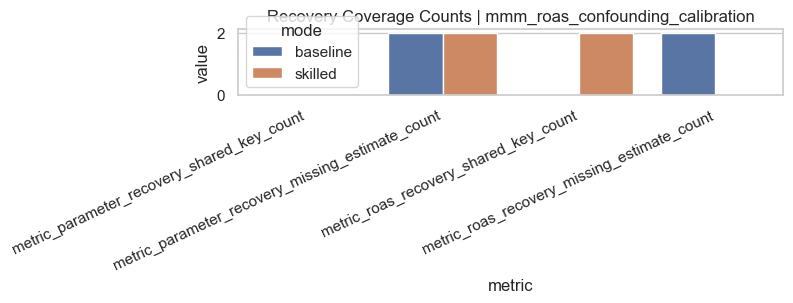

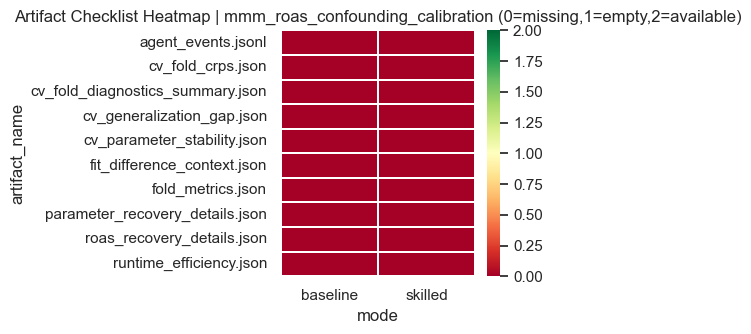

In [8]:
display(Markdown("## Per-Task Visual Enhancements"))

for task_id in sorted(run_df["task_id"].unique()):
    task_runs = run_df[run_df["task_id"] == task_id].copy()
    display(Markdown(f"### Visual Layer: `{task_id}`"))

    health_plot = task_runs[["mode"]].copy()
    health_plot["status_flag"] = task_runs["status"].eq("success").astype(int)
    health_plot["folds_valid_flag"] = task_runs["folds_valid"].fillna(False).astype(int)
    health_plot["payload_validation_error_count"] = task_runs[
        "payload_validation_error_count"
    ].fillna(0)
    health_plot["divergence_count"] = task_runs[
        "metric_convergence_divergence_count"
    ].fillna(0)

    health_heat = health_plot.set_index("mode")
    plt.figure(figsize=(6, 2.8))
    sns.heatmap(health_heat, annot=True, fmt=".2g", cmap="YlGnBu", linewidths=0.5)
    plt.title(f"Run Health Matrix | {task_id}")
    plt.tight_layout()

    perf_metrics = [
        "metric_crps_oos",
        "metric_crps_cv_mean",
        "metric_in_sample_crps",
        "metric_in_sample_mae",
    ]
    perf_metrics = [m for m in perf_metrics if m in task_runs.columns]
    perf_values = (
        task_runs[["mode", *perf_metrics]]
        .melt(
            id_vars=["mode"],
            var_name="metric",
            value_name="value",
        )
        .dropna(subset=["value"])
    )

    if perf_values.empty:
        display(
            Markdown(
                "_No finite performance values available for normalized comparison._"
            )
        )
    else:
        perf_values["scaled_value"] = perf_values.groupby("metric")["value"].transform(
            lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5
        )
        plt.figure(figsize=(8.5, 3.2))
        sns.scatterplot(
            data=perf_values,
            x="metric",
            y="scaled_value",
            hue="mode",
            s=110,
        )
        plt.title(f"Normalized Performance Comparison | {task_id}")
        plt.xticks(rotation=25, ha="right")
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()

    runtime_scatter_df = task_runs[
        ["mode", "metric_runtime_per_fold_sec", "metric_folds_per_second"]
    ].dropna()
    if runtime_scatter_df.empty:
        display(
            Markdown(
                "_Runtime efficiency scatter unavailable (missing per-fold metrics)._"
            )
        )
    else:
        plt.figure(figsize=(6.5, 3.2))
        sns.scatterplot(
            data=runtime_scatter_df,
            x="metric_runtime_per_fold_sec",
            y="metric_folds_per_second",
            hue="mode",
            s=120,
        )
        for _, row in runtime_scatter_df.iterrows():
            plt.annotate(
                row["mode"],
                (row["metric_runtime_per_fold_sec"], row["metric_folds_per_second"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )
        plt.title(f"Runtime Efficiency Tradeoff | {task_id}")
        plt.tight_layout()

    stability_records = []
    for _, row in task_runs.iterrows():
        details = _safe_json_load(
            Path(row.get("artifacts_path", "")) / "cv_parameter_stability.json"
        )
        by_parameter = (
            details.get("by_parameter", {}) if isinstance(details, dict) else {}
        )
        for parameter_name, stats in by_parameter.items():
            stability_records.append(
                {
                    "mode": row.get("mode"),
                    "parameter": parameter_name,
                    "std": stats.get("std"),
                    "coefvar": stats.get("coefvar"),
                }
            )

    stability_df = pd.DataFrame(stability_records)
    if stability_df.empty:
        display(Markdown("_Parameter stability heatmap not available for this task._"))
    else:
        std_pivot = stability_df.pivot_table(
            index="parameter",
            columns="mode",
            values="std",
            aggfunc="mean",
        )
        plt.figure(figsize=(6.5, max(2.8, 0.3 * len(std_pivot))))
        sns.heatmap(std_pivot, cmap="magma", annot=True, fmt=".3g", linewidths=0.3)
        plt.title(f"Parameter Stability Heatmap (std) | {task_id}")
        plt.tight_layout()

    recovery_count_cols = [
        "metric_parameter_recovery_shared_key_count",
        "metric_parameter_recovery_missing_estimate_count",
        "metric_roas_recovery_shared_key_count",
        "metric_roas_recovery_missing_estimate_count",
    ]
    available_recovery_count_cols = [
        c for c in recovery_count_cols if c in task_runs.columns
    ]
    recovery_counts = (
        task_runs[["mode", *available_recovery_count_cols]]
        .melt(
            id_vars=["mode"],
            var_name="metric",
            value_name="value",
        )
        .dropna(subset=["value"])
        if available_recovery_count_cols
        else pd.DataFrame()
    )

    if recovery_counts.empty:
        display(Markdown("_Recovery coverage panel unavailable for this task._"))
    else:
        plt.figure(figsize=(8, 3.2))
        sns.barplot(data=recovery_counts, x="metric", y="value", hue="mode")
        plt.title(f"Recovery Coverage Counts | {task_id}")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()

    coverage_task = artifact_coverage_df[
        artifact_coverage_df["task_id"] == task_id
    ].copy()
    state_map = {"missing": 0, "empty": 1, "available": 2}
    coverage_task["state_code"] = coverage_task["artifact_state"].map(state_map)
    cov_pivot = coverage_task.pivot_table(
        index="artifact_name",
        columns="mode",
        values="state_code",
        aggfunc="max",
    )
    if cov_pivot.empty:
        display(Markdown("_Artifact checklist heatmap unavailable for this task._"))
    else:
        plt.figure(figsize=(5.5, max(2.5, 0.35 * len(cov_pivot))))
        sns.heatmap(cov_pivot, cmap="RdYlGn", vmin=0, vmax=2, linewidths=0.3)
        plt.title(
            f"Artifact Checklist Heatmap | {task_id} (0=missing,1=empty,2=available)"
        )
        plt.tight_layout()

In [9]:
display(Markdown("## Appendix and Traceability"))

appendix_run_cols = [
    "task_id",
    "task_type",
    "mode",
    "seed",
    "status",
    "runtime_sec",
    "folds_valid",
    "payload_validation_error_count",
    "metric_crps_oos",
    "metric_crps_cv_mean",
    "metric_in_sample_crps",
    "metric_cv_rhat_max",
    "metric_cv_ess_bulk_min",
    "metric_runtime_per_fold_sec",
    "metric_folds_per_second",
    "metric_parameter_recovery_mae",
    "metric_roas_recovery_mae",
    "artifacts_path",
    "agent_events_path",
]
appendix_run_cols = [c for c in appendix_run_cols if c in run_df.columns]

display(Markdown("### Run Results (Key Columns)"))
display(run_df[appendix_run_cols].sort_values(["task_id", "mode", "seed"]))

display(Markdown("### Paired Deltas (Full)"))
display(paired_df.sort_values(["task_id", "seed"]))

display(Markdown("### Artifact Inventory by Run"))
artifact_inventory = (
    artifact_coverage_df.groupby(
        ["task_id", "mode", "seed", "artifact_state"], as_index=False
    )
    .size()
    .rename(columns={"size": "artifact_count"})
    .sort_values(["task_id", "mode", "seed", "artifact_state"])
)
display(artifact_inventory)

display(Markdown("### Missing or Empty Artifact Paths"))
missing_artifacts = artifact_coverage_df[
    artifact_coverage_df["artifact_state"].isin(["missing", "empty"])
].copy()
if missing_artifacts.empty:
    display(Markdown("All expected artifacts are available."))
else:
    display(
        missing_artifacts[
            [
                "task_id",
                "mode",
                "seed",
                "artifact_name",
                "artifact_state",
                "artifact_reason",
                "artifact_path",
            ]
        ].sort_values(["task_id", "mode", "seed", "artifact_name"])
    )

display(Markdown("### Agent Event Traceability"))
if "agent_events_path" in run_df.columns:
    events_trace_df = run_df[["task_id", "mode", "seed", "agent_events_path"]].copy()
    events_trace_df["agent_events_exists"] = events_trace_df["agent_events_path"].apply(
        lambda p: Path(str(p)).exists() if pd.notna(p) else False
    )
    display(events_trace_df.sort_values(["task_id", "mode", "seed"]))
else:
    display(Markdown("`agent_events_path` not available in `run_results.csv`."))

## Appendix and Traceability

### Run Results (Key Columns)

,task_id,task_type,mode,seed,status,runtime_sec,folds_valid,payload_validation_error_count,metric_crps_oos,metric_crps_cv_mean,metric_in_sample_crps,metric_cv_rhat_max,metric_cv_ess_bulk_min,metric_runtime_per_fold_sec,metric_folds_per_second,metric_parameter_recovery_mae,metric_roas_recovery_mae,artifacts_path,agent_events_path
0,mmm_case_study_1d,mmm_1d,baseline,42,success,468.995113,True,0,2.435746e+07,2.435746e+07,2.270392e+07,1.01,602.0,156.331704,0.006397,NaN,NaN,benchmark/results/latest/artifacts/mmm_case_st...,benchmark/results/latest/artifacts/mmm_case_st...
1,mmm_case_study_1d,mmm_1d,skilled,42,success,278.503424,True,0,2.089775e+07,2.089775e+07,2.213902e+07,1.01,693.0,92.834475,0.010772,NaN,NaN,benchmark/results/latest/artifacts/mmm_case_st...,benchmark/results/latest/artifacts/mmm_case_st...
2,mmm_multidimensional_recovery,mmm_multidimensional,baseline,42,failure,541.028602,False,2,NaN,NaN,NaN,NaN,NaN,541.028602,0.001848,NaN,NaN,benchmark/results/latest/artifacts/mmm_multidi...,benchmark/results/latest/artifacts/mmm_multidi...
3,mmm_multidimensional_recovery,mmm_multidimensional,skilled,42,failure,618.898836,False,44,NaN,NaN,NaN,NaN,NaN,618.898836,0.001616,NaN,NaN,benchmark/results/latest/artifacts/mmm_multidi...,benchmark/results/latest/artifacts/mmm_multidi...
4,mmm_roas_confounding_calibration,mmm_roas_confounding,baseline,42,failure,758.741851,False,3,NaN,NaN,NaN,NaN,NaN,758.741851,0.001318,NaN,NaN,benchmark/results/latest/artifacts/mmm_roas_co...,benchmark/results/latest/artifacts/mmm_roas_co...
5,mmm_roas_confounding_calibration,mmm_roas_confounding,skilled,42,success,2071.514673,True,0,4.336972e+02,4.336972e+02,NaN,1.02,377.0,517.878668,0.001931,NaN,13.375916,benchmark/results/latest/artifacts/mmm_roas_co...,benchmark/results/latest/artifacts/mmm_roas_co...


### Paired Deltas (Full)

,task_id,seed,delta_convergence_divergence_count,delta_crps_cv_mean,delta_crps_cv_std,delta_crps_oos,delta_cv_divergence_max,delta_cv_divergence_mean,delta_cv_ess_bulk_min,delta_cv_mean_crps,delta_cv_n_folds,delta_cv_param_count,delta_cv_param_cv_mean,delta_cv_param_iqr_mean,delta_cv_param_range_mean,delta_cv_param_std_mean,delta_cv_rhat_max,delta_folds_per_second,delta_in_sample_crps,delta_in_sample_mae,delta_in_sample_rmse,delta_runtime_per_fold_sec,delta_runtime_sec,delta_parameter_recovery_missing_estimate_count,delta_parameter_recovery_missing_truth_count,delta_parameter_recovery_shared_key_count,delta_roas_recovery_missing_estimate_count,delta_roas_recovery_missing_truth_count,delta_roas_recovery_shared_key_count
0,mmm_case_study_1d,42,-9.0,-3.459705e+06,2.166510e+06,-3.459705e+06,-11.0,-7.0,91.0,-3.459705e+06,0.0,0.0,0.042149,0.028738,0.057476,0.025486,0.0,0.004375,-564894.64212,-835428.923772,-443939.812183,-63.497230,-190.491689,NaN,NaN,NaN,NaN,NaN,NaN
1,mmm_multidimensional_recovery,42,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,-0.000233,NaN,NaN,NaN,77.870234,77.870234,0.0,0.0,0.0,0.0,0.0,0.0
2,mmm_roas_confounding_calibration,42,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,0.000613,NaN,NaN,NaN,-240.863183,1312.772821,0.0,7.0,0.0,-2.0,0.0,2.0


...

,task_id,mode,seed,artifact_state,artifact_count
0,mmm_case_study_1d,baseline,42,missing,10
1,mmm_case_study_1d,skilled,42,missing,10
2,mmm_multidimensional_recovery,baseline,42,missing,10
3,mmm_multidimensional_recovery,skilled,42,missing,10
4,mmm_roas_confounding_calibration,baseline,42,missing,10
5,mmm_roas_confounding_calibration,skilled,42,missing,10


### Missing or Empty Artifact Paths

,task_id,mode,seed,artifact_name,artifact_state,artifact_reason,artifact_path
9,mmm_case_study_1d,baseline,42,agent_events.jsonl,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
6,mmm_case_study_1d,baseline,42,cv_fold_crps.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
2,mmm_case_study_1d,baseline,42,cv_fold_diagnostics_summary.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
5,mmm_case_study_1d,baseline,42,cv_generalization_gap.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
3,mmm_case_study_1d,baseline,42,cv_parameter_stability.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
0,mmm_case_study_1d,baseline,42,fit_difference_context.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
4,mmm_case_study_1d,baseline,42,fold_metrics.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
7,mmm_case_study_1d,baseline,42,parameter_recovery_details.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
8,mmm_case_study_1d,baseline,42,roas_recovery_details.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...
1,mmm_case_study_1d,baseline,42,runtime_efficiency.json,missing,artifact file not found,benchmark/results/latest/artifacts/mmm_case_st...


### Agent Event Traceability

,task_id,mode,seed,agent_events_path,agent_events_exists
0,mmm_case_study_1d,baseline,42,benchmark/results/latest/artifacts/mmm_case_st...,False
1,mmm_case_study_1d,skilled,42,benchmark/results/latest/artifacts/mmm_case_st...,False
2,mmm_multidimensional_recovery,baseline,42,benchmark/results/latest/artifacts/mmm_multidi...,False
3,mmm_multidimensional_recovery,skilled,42,benchmark/results/latest/artifacts/mmm_multidi...,False
4,mmm_roas_confounding_calibration,baseline,42,benchmark/results/latest/artifacts/mmm_roas_co...,False
5,mmm_roas_confounding_calibration,skilled,42,benchmark/results/latest/artifacts/mmm_roas_co...,False


### Appendix Visual Summaries

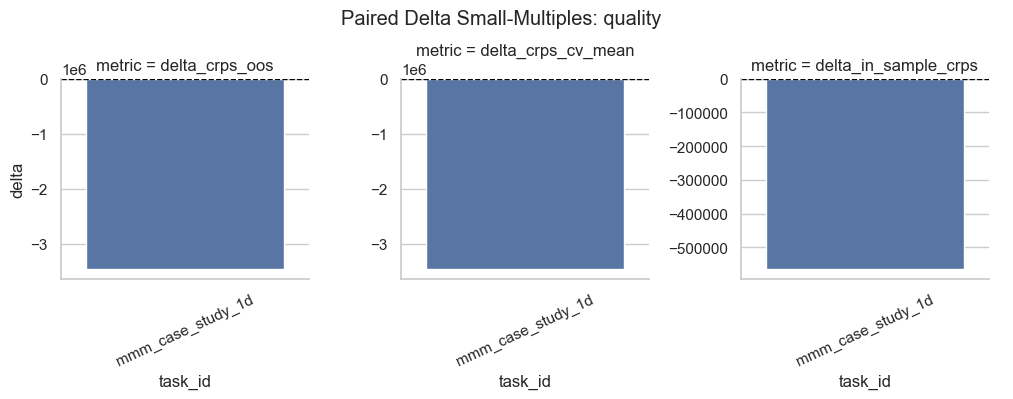

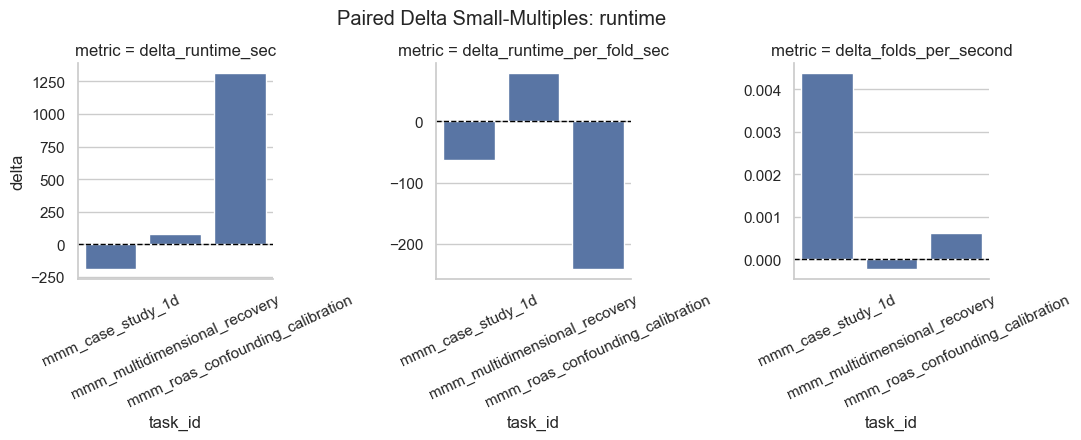

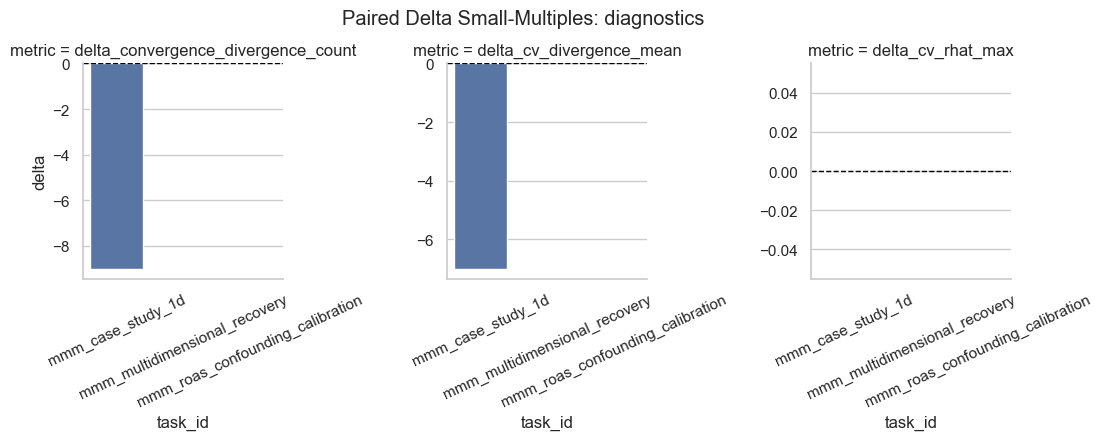

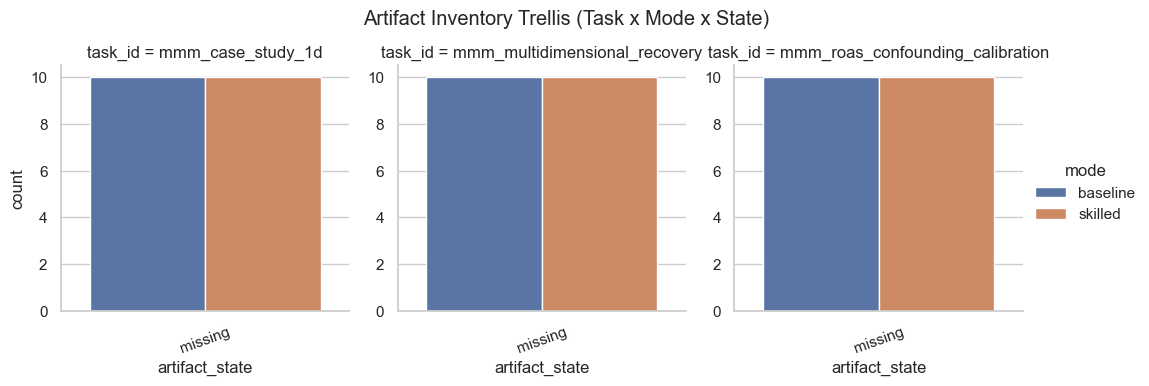

In [10]:
display(Markdown("### Appendix Visual Summaries"))

key_delta_groups = {
    "quality": ["delta_crps_oos", "delta_crps_cv_mean", "delta_in_sample_crps"],
    "runtime": [
        "delta_runtime_sec",
        "delta_runtime_per_fold_sec",
        "delta_folds_per_second",
    ],
    "diagnostics": [
        "delta_convergence_divergence_count",
        "delta_cv_divergence_mean",
        "delta_cv_rhat_max",
    ],
}

for group_name, columns in key_delta_groups.items():
    available = [c for c in columns if c in paired_df.columns]
    if not available:
        continue

    group_plot = (
        paired_df[["task_id", *available]]
        .melt(
            id_vars=["task_id"],
            var_name="metric",
            value_name="delta",
        )
        .dropna(subset=["delta"])
    )

    if group_plot.empty:
        continue

    g = sns.catplot(
        data=group_plot,
        x="task_id",
        y="delta",
        col="metric",
        kind="bar",
        sharey=False,
        height=3.2,
        aspect=1.05,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.tick_params(axis="x", rotation=25)
    g.fig.suptitle(f"Paired Delta Small-Multiples: {group_name}", y=1.05)

inventory_plot = (
    artifact_coverage_df.groupby(["task_id", "mode", "artifact_state"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

if not inventory_plot.empty:
    g = sns.catplot(
        data=inventory_plot,
        x="artifact_state",
        y="count",
        hue="mode",
        col="task_id",
        kind="bar",
        sharey=False,
        height=3.5,
        aspect=1,
    )
    g.fig.suptitle("Artifact Inventory Trellis (Task x Mode x State)", y=1.05)
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=20)

In [11]:
display(Markdown("## Optional Deep-Diagnostic Views"))

fold_crps_rows = []
fit_context_rows = []

for _, row in run_df.iterrows():
    base = Path(row.get("artifacts_path", ""))

    fold_crps_path = base / "cv_fold_crps.json"
    fold_payload = _safe_json_load(fold_crps_path)
    if isinstance(fold_payload, list):
        for item in fold_payload:
            fold_idx = item.get("fold_idx")
            for split_key in ["crps_train", "crps_test"]:
                value = item.get(split_key)
                if value is None:
                    continue
                fold_crps_rows.append(
                    {
                        "task_id": row.get("task_id"),
                        "mode": row.get("mode"),
                        "seed": row.get("seed"),
                        "fold_idx": fold_idx,
                        "split": split_key.replace("crps_", ""),
                        "crps": value,
                    }
                )

    fit_context_path = base / "fit_difference_context.json"
    fit_payload = _safe_json_load(fit_context_path)
    if isinstance(fit_payload, dict):
        fit_context_rows.append(
            {
                "task_id": row.get("task_id"),
                "mode": row.get("mode"),
                "seed": row.get("seed"),
                "status": fit_payload.get("status"),
                "runtime_sec": fit_payload.get("runtime_sec"),
                "cv_fold_count": fit_payload.get("cv_fold_count"),
                "payload_validation_error_count": fit_payload.get(
                    "payload_validation_error_count"
                ),
                "convergence_is_converged": fit_payload.get("convergence", {}).get(
                    "is_converged"
                ),
                "convergence_divergence_count": fit_payload.get("convergence", {}).get(
                    "divergence_count"
                ),
            }
        )

fold_crps_df = pd.DataFrame(fold_crps_rows)
fit_context_df = pd.DataFrame(fit_context_rows)

if fold_crps_df.empty:
    display(
        Markdown("No `cv_fold_crps.json` payloads available for trajectory plotting.")
    )
else:
    g = sns.relplot(
        data=fold_crps_df,
        x="fold_idx",
        y="crps",
        hue="split",
        style="mode",
        col="task_id",
        kind="line",
        markers=True,
        dashes=False,
        facet_kws={"sharey": False},
        height=4,
        aspect=1.1,
    )
    g.fig.suptitle("Fold CRPS Trajectories (Train/Test)", y=1.03)

if fit_context_df.empty:
    display(Markdown("No `fit_difference_context.json` payloads were available."))
else:
    display(Markdown("### Fit Difference Context Summary"))
    display(fit_context_df.sort_values(["task_id", "mode", "seed"]))

## Optional Deep-Diagnostic Views

No `cv_fold_crps.json` payloads available for trajectory plotting.

No `fit_difference_context.json` payloads were available.

In [12]:
display(Markdown("### Fold CRPS Distribution View"))

if "fold_crps_df" not in globals() or fold_crps_df.empty:
    display(
        Markdown(
            "Fold CRPS distribution plot unavailable (no fold-level CRPS payloads)."
        )
    )
else:
    plt.figure(figsize=(9, 4.2))
    sns.boxplot(data=fold_crps_df, x="split", y="crps", hue="mode")
    plt.title("Fold CRPS Distribution by Split and Mode")
    if fold_crps_df["crps"].max() / max(fold_crps_df["crps"].min(), 1e-12) > 50:
        plt.yscale("log")
    plt.tight_layout()

    plt.figure(figsize=(9, 4.2))
    sns.violinplot(data=fold_crps_df, x="split", y="crps", hue="mode", cut=0)
    plt.title("Fold CRPS Density by Split and Mode")
    if fold_crps_df["crps"].max() / max(fold_crps_df["crps"].min(), 1e-12) > 50:
        plt.yscale("log")
    plt.tight_layout()

### Fold CRPS Distribution View

Fold CRPS distribution plot unavailable (no fold-level CRPS payloads).